In [79]:
# CODEWORKOUT FALL 2019 (EDA)
# Project: JY1

import pandas as pd #importing libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Pandas version: 2.2.2
NumPy version: 1.26.4


In [80]:
#Loading data

import os

print("Loading CodeWorkout Fall 2019 dataset...")


main_df = pd.read_csv('MainTable.csv')
grades_df = pd.read_csv('Subject.csv')
early_df = pd.read_csv('early.csv')
late_df = pd.read_csv('late.csv')

print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"Main table rows:        {len(main_df):,}")
print(f"Students with grades:   {len(grades_df):,}")
print(f"Early phase rows:       {len(early_df):,}")
print(f"Late phase rows:        {len(late_df):,}")
print("="*70)

# Quick check about data
print("\n Quick Check:")
print(f"Main table columns: {len(main_df.columns)}")
print(f"Grades columns: {list(grades_df.columns)}")
print(f"Early columns: {list(early_df.columns)}")

Loading CodeWorkout Fall 2019 dataset...
DATASET OVERVIEW
Main table rows:        360,176
Students with grades:   506
Early phase rows:       14,317
Late phase rows:        9,386

 Quick Check:
Main table columns: 17
Grades columns: ['SubjectID', 'X-Grade']
Early columns: ['SubjectID', 'AssignmentID', 'ProblemID', 'Attempts', 'CorrectEventually', 'Label']


In [81]:
#data preview
 
print("\n" + "="*70)
print("MAIN TABLE - FIRST 5 ROWS")
print("="*70)
print(main_df.head())
 
print("\n" + "="*70)
print("GRADES TABLE - FIRST 10 ROWS")
print("="*70)
print(grades_df.head(10))
 
print("\n" + "="*70)
print("EARLY PHASE DATA - FIRST 5 ROWS")
print("="*70)
print(early_df.head())


MAIN TABLE - FIRST 5 ROWS
                                           SubjectID        ToolInstances  \
0  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...  Java 8; CodeWorkout   
1  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...  Java 8; CodeWorkout   
2  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...  Java 8; CodeWorkout   
3  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...  Java 8; CodeWorkout   
4  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...  Java 8; CodeWorkout   

       ServerTimestamp  ServerTimezone CourseID  AssignmentID  ProblemID  \
0  2019-09-27T12:43:31               0     CS 1           439          1   
1  2019-09-27T12:43:31               0     CS 1           439          1   
2  2019-09-27T12:46:46               0     CS 1           439          3   
3  2019-09-27T12:46:46               0     CS 1           439          3   
4  2019-09-27T12:46:46               0     CS 1           439          3   

                                         CodeStateID 

In [82]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4: DATA STRUCTURE ANALYSIS
# ═══════════════════════════════════════════════════════════════════
 
print("\n" + "="*70)
print("MAIN TABLE STRUCTURE")
print("="*70)
print(main_df.info())
 
print("\n" + "="*70)
print("COLUMN NAMES")
print("="*70)
print("Main table columns:", main_df.columns.tolist())
print("\nGrades columns:", grades_df.columns.tolist())
print("\nEarly phase columns:", early_df.columns.tolist())


MAIN TABLE STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360176 entries, 0 to 360175
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   SubjectID                  360176 non-null  object 
 1   ToolInstances              360176 non-null  object 
 2   ServerTimestamp            360176 non-null  object 
 3   ServerTimezone             360176 non-null  int64  
 4   CourseID                   360176 non-null  object 
 5   AssignmentID               360176 non-null  int64  
 6   ProblemID                  360176 non-null  int64  
 7   CodeStateID                360176 non-null  object 
 8   IsEventOrderingConsistent  360176 non-null  bool   
 9   EventType                  360176 non-null  object 
 10  Score                      125578 non-null  float64
 11  Compile.Result             125578 non-null  object 
 12  CompileMessageType         109020 non-null  object 
 13  Compile

In [83]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5: BASIC STATISTICS
# ═══════════════════════════════════════════════════════════════════
 
print("\n" + "="*70)
print("DATASET STATISTICS")
print("="*70)
 
# Studentlevel statistics
n_students = main_df['SubjectID'].nunique()
n_events = len(main_df)
n_problems = main_df['ProblemID'].nunique()
n_assignments = main_df['AssignmentID'].nunique()
 
print(f"\n Overall Statistics:")
print(f"  Total students:           {n_students:,}")
print(f"  Total events:             {n_events:,}")
print(f"  Total problems:           {n_problems}")
print(f"  Total assignments:        {n_assignments}")
print(f"  Avg events per student:   {n_events/n_students:.1f}")
 
# Event types
print(f"\n Event Type Distribution:")
print(main_df['EventType'].value_counts())
 
# Submission statistics
run_events = main_df[main_df['EventType'] == 'Run.Program'].copy()
print(f"\n Submission Statistics:")
print(f"  Total submission attempts: {len(run_events):,}")
print(f"  Avg submissions/student:   {len(run_events)/n_students:.1f}")
 
# Score distribution
print(f"\n Score Distribution:")
print(run_events['Score'].value_counts().sort_index())
print(f"\n  Average score:             {run_events['Score'].mean():.3f}")
print(f"  Median score:              {run_events['Score'].median():.3f}")
print(f"  Success rate (Score=1.0):  {(run_events['Score'] == 1.0).mean():.1%}")
 
# Compile results
compile_events = main_df[main_df['EventType'] == 'Compile'].copy()
print(f"\n Compile Results:")
print(compile_events['Compile.Result'].value_counts())
 
if len(compile_events) > 0:
    success_rate = (compile_events['Compile.Result'] == 'Success').mean()
    error_rate = (compile_events['Compile.Result'] == 'Error').mean()
    print(f"\n  Compile success rate:      {success_rate:.1%}")
    print(f"  Compile error rate:        {error_rate:.1%}")
 
# Grade statistics
print(f"\n Grade Statistics:")
print(grades_df['X-Grade'].describe())
print(f"\n  Grade range:               {grades_df['X-Grade'].min():.1f} - {grades_df['X-Grade'].max():.1f}")
print(f"  Students with grades:      {len(grades_df)} out of {n_students}")


DATASET STATISTICS

 Overall Statistics:
  Total students:           506
  Total events:             360,176
  Total problems:           50
  Total assignments:        5
  Avg events per student:   711.8

 Event Type Distribution:
EventType
Run.Program      125578
Compile          125578
Compile.Error    109020
Name: count, dtype: int64

 Submission Statistics:
  Total submission attempts: 125,578
  Avg submissions/student:   248.2

 Score Distribution:
Score
0.000000    54614
0.035714       89
0.038462        3
0.040000      112
0.045455        4
            ...  
0.956522       52
0.960000      240
0.961538       19
0.964286        6
1.000000    24680
Name: count, Length: 213, dtype: int64

  Average score:             0.397
  Median score:              0.273
  Success rate (Score=1.0):  19.7%

 Compile Results:
Compile.Result
Success    75374
Error      50204
Name: count, dtype: int64

  Compile success rate:      60.0%
  Compile error rate:        40.0%

 Grade Statistics:
count  

In [84]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6: MISSING VALUES CHECK
# ═══════════════════════════════════════════════════════════════════
 
print("\n" + "="*70)
print("MISSING VALUES CHECK")
print("="*70)
 
print("\nMain table missing values:")
missing_main = main_df.isnull().sum()
missing_pct = (missing_main / len(main_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_main,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])
 
print("\nGrades missing values:")
print(grades_df.isnull().sum())


MISSING VALUES CHECK

Main table missing values:
                    Missing Count  Percentage
Score                      234598       65.13
Compile.Result             234598       65.13
CompileMessageType         251156       69.73
CompileMessageData         251156       69.73
ParentEventID              125578       34.87

Grades missing values:
SubjectID    0
X-Grade      0
dtype: int64


In [85]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7: DATA QUALITY CHECKS
# ═══════════════════════════════════════════════════════════════════
 
print("\n" + "="*70)
print("DATA QUALITY REPORT")
print("="*70)
 
quality_issues = []
 
# Check 1: Duplicates
duplicates = main_df.duplicated().sum()
print(f"\n1. Duplicate rows: {duplicates}")
if duplicates > 0:
    quality_issues.append(f"Found {duplicates} duplicate rows")
 
# Check 2: Invalid scores
invalid_scores = run_events[(run_events['Score'] < 0) | (run_events['Score'] > 1)]
print(f"2. Invalid scores (not 0-1): {len(invalid_scores)}")
if len(invalid_scores) > 0:
    quality_issues.append(f"Found {len(invalid_scores)} invalid scores")
 
# Check 3: Invalid grades
invalid_grades = grades_df[(grades_df['X-Grade'] < 0) | (grades_df['X-Grade'] > 100)]
print(f"3. Invalid grades (not 0-100): {len(invalid_grades)}")
if len(invalid_grades) > 0:
    quality_issues.append(f"Found {len(invalid_grades)} invalid grades")
 
# Check 4: Student coverage
students_with_grades = len(grades_df)
coverage = (students_with_grades / n_students) * 100
print(f"4. Student coverage: {coverage:.1f}% ({students_with_grades}/{n_students})")
if coverage < 95:
    quality_issues.append(f"Only {coverage:.1f}% of students have grades")
 
# Summary
print("\n" + "="*70)
if len(quality_issues) == 0:
    print(" DATA QUALITY: EXCELLENT! No major issues found.")
else:
    print(" DATA QUALITY ISSUES:")
    for issue in quality_issues:
        print(f"  - {issue}")
print("="*70)
 


DATA QUALITY REPORT

1. Duplicate rows: 0
2. Invalid scores (not 0-1): 0
3. Invalid grades (not 0-100): 0
4. Student coverage: 100.0% (506/506)

 DATA QUALITY: EXCELLENT! No major issues found.


In [86]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8: STUDENT-LEVEL AGGREGATION
# ═══════════════════════════════════════════════════════════════════
 
print("\n" + "="*70)
print("STUDENT LEVEL ANALYSIS")
print("="*70)
 
# Events per student
events_per_student = main_df.groupby('SubjectID').size()
print(f"\n Events per Student:")
print(f"  Mean:   {events_per_student.mean():.1f}")
print(f"  Median: {events_per_student.median():.1f}")
print(f"  Min:    {events_per_student.min()}")
print(f"  Max:    {events_per_student.max()}")
 
# Problems per student
problems_per_student = main_df.groupby('SubjectID')['ProblemID'].nunique()
print(f"\n Problems Attempted per Student:")
print(f"  Mean:   {problems_per_student.mean():.1f}")
print(f"  Median: {problems_per_student.median():.1f}")
print(f"  Min:    {problems_per_student.min()}")
print(f"  Max:    {problems_per_student.max()}")
 
# Submissions per student
submissions_per_student = run_events.groupby('SubjectID').size()
print(f"\n Submissions per Student:")
print(f"  Mean:   {submissions_per_student.mean():.1f}")
print(f"  Median: {submissions_per_student.median():.1f}")
print(f"  Min:    {submissions_per_student.min()}")
print(f"  Max:    {submissions_per_student.max()}")


STUDENT LEVEL ANALYSIS

 Events per Student:
  Mean:   711.8
  Median: 617.0
  Min:    57
  Max:    2775

 Problems Attempted per Student:
  Mean:   47.5
  Median: 50.0
  Min:    9
  Max:    50

 Submissions per Student:
  Mean:   248.2
  Median: 217.0
  Min:    26
  Max:    907


 Saved: 01_grade_distribution.png


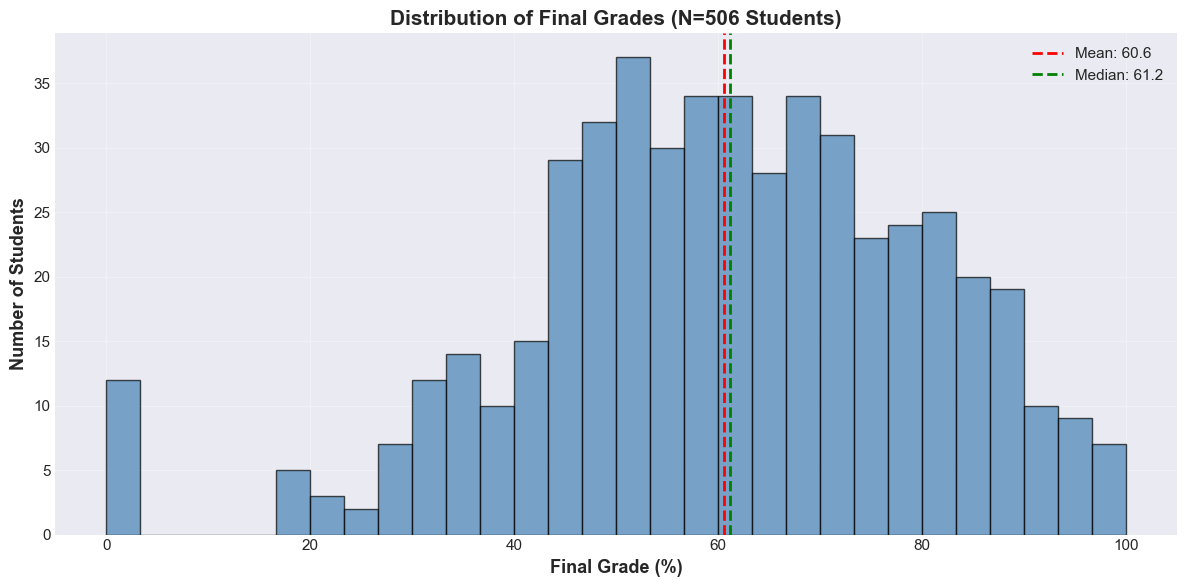

In [87]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9: VISUALIZATION 1 - GRADE DISTRIBUTION
# ═══════════════════════════════════════════════════════════════════
 
plt.figure(figsize=(12, 6))
plt.hist(grades_df['X-Grade'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(grades_df['X-Grade'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {grades_df["X-Grade"].mean():.1f}')
plt.axvline(grades_df['X-Grade'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {grades_df["X-Grade"].median():.1f}')
plt.xlabel('Final Grade (%)', fontsize=13, fontweight='bold')
plt.ylabel('Number of Students', fontsize=13, fontweight='bold')
plt.title('Distribution of Final Grades (N=506 Students)', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('01_grade_distribution.png', dpi=300, bbox_inches='tight')
print(" Saved: 01_grade_distribution.png")
plt.show()

 Saved: 02_score_distribution.png


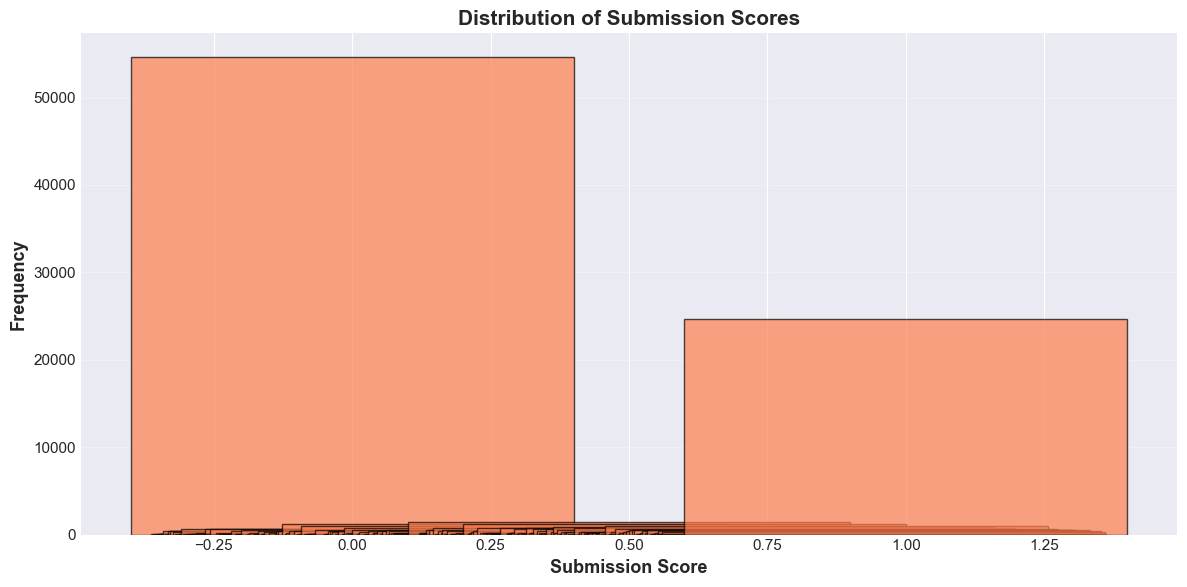

In [88]:
# ═══════════════════════════════════════════════════════════════════
# CELL 10: VISUALIZATION 2 - SCORE DISTRIBUTION
# ═══════════════════════════════════════════════════════════════════
 
plt.figure(figsize=(12, 6))
score_counts = run_events['Score'].value_counts().sort_index()
plt.bar(score_counts.index, score_counts.values, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Submission Score', fontsize=13, fontweight='bold')
plt.ylabel('Frequency', fontsize=13, fontweight='bold')
plt.title('Distribution of Submission Scores', fontsize=15, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('02_score_distribution.png', dpi=300, bbox_inches='tight')
print(" Saved: 02_score_distribution.png")
plt.show()

 Saved: 03_compile_results.png


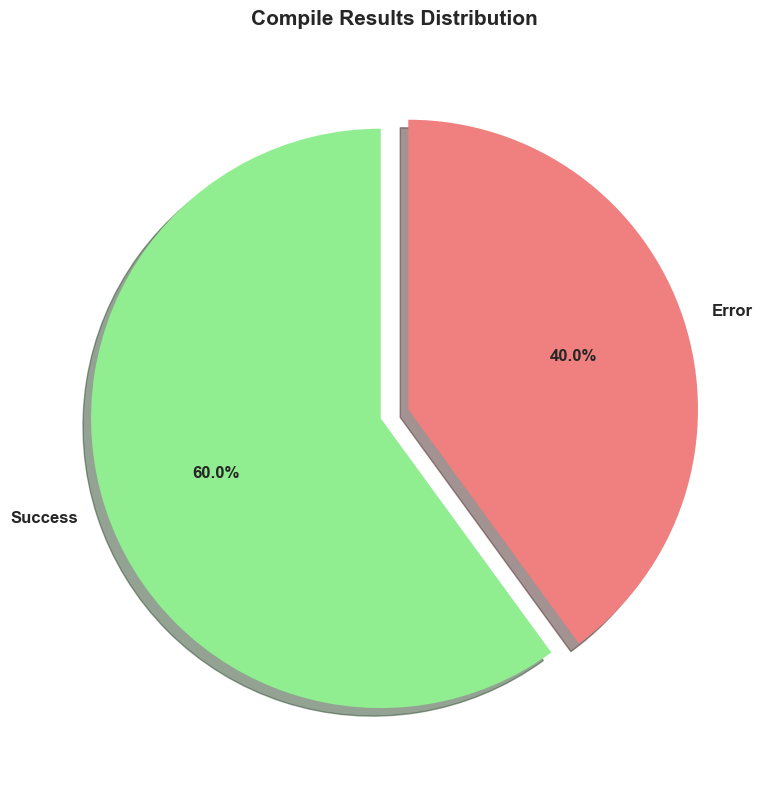

In [89]:
# ═══════════════════════════════════════════════════════════════════
# CELL 11: VISUALIZATION 3 - COMPILE RESULTS PIE CHART
# ═══════════════════════════════════════════════════════════════════
 
plt.figure(figsize=(10, 8))
compile_counts = compile_events['Compile.Result'].value_counts()
colors = ['lightgreen', 'lightcoral']
explode = (0.05, 0.05)
plt.pie(compile_counts, labels=compile_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors, explode=explode, shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Compile Results Distribution', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('03_compile_results.png', dpi=300, bbox_inches='tight')
print(" Saved: 03_compile_results.png")
plt.show()

 Saved: 04_events_per_student.png


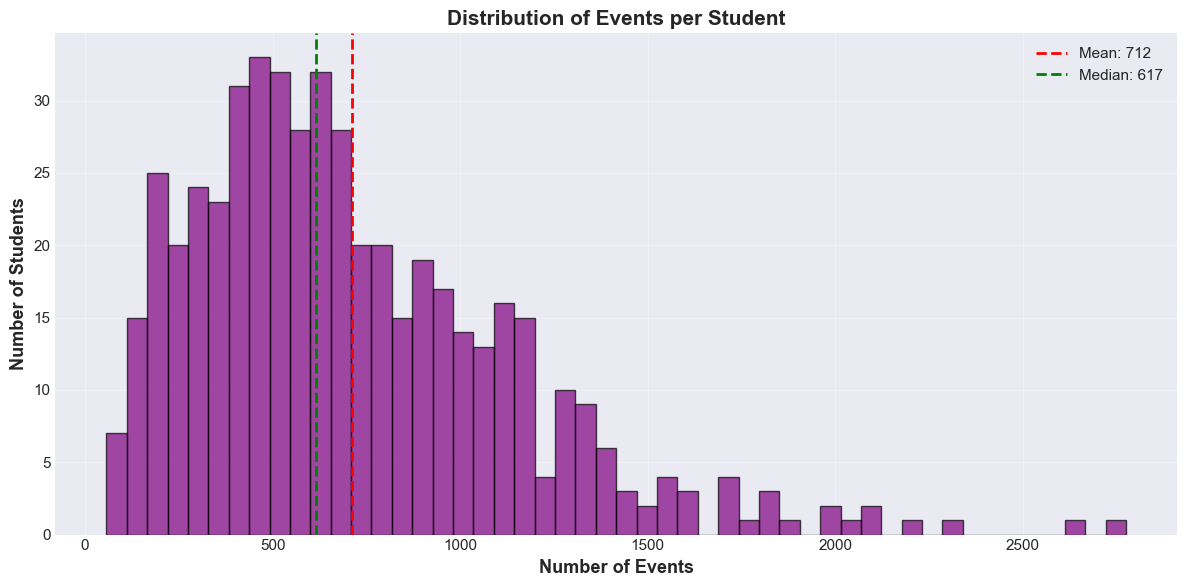

In [90]:
# ═══════════════════════════════════════════════════════════════════
# CELL 12: VISUALIZATION 4 - EVENTS PER STUDENT
# ═══════════════════════════════════════════════════════════════════
 
plt.figure(figsize=(12, 6))
plt.hist(events_per_student, bins=50, edgecolor='black', alpha=0.7, color='purple')
plt.axvline(events_per_student.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {events_per_student.mean():.0f}')
plt.axvline(events_per_student.median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {events_per_student.median():.0f}')
plt.xlabel('Number of Events', fontsize=13, fontweight='bold')
plt.ylabel('Number of Students', fontsize=13, fontweight='bold')
plt.title('Distribution of Events per Student', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('04_events_per_student.png', dpi=300, bbox_inches='tight')
print(" Saved: 04_events_per_student.png")
plt.show()

 Saved: 05_problems_per_student.png


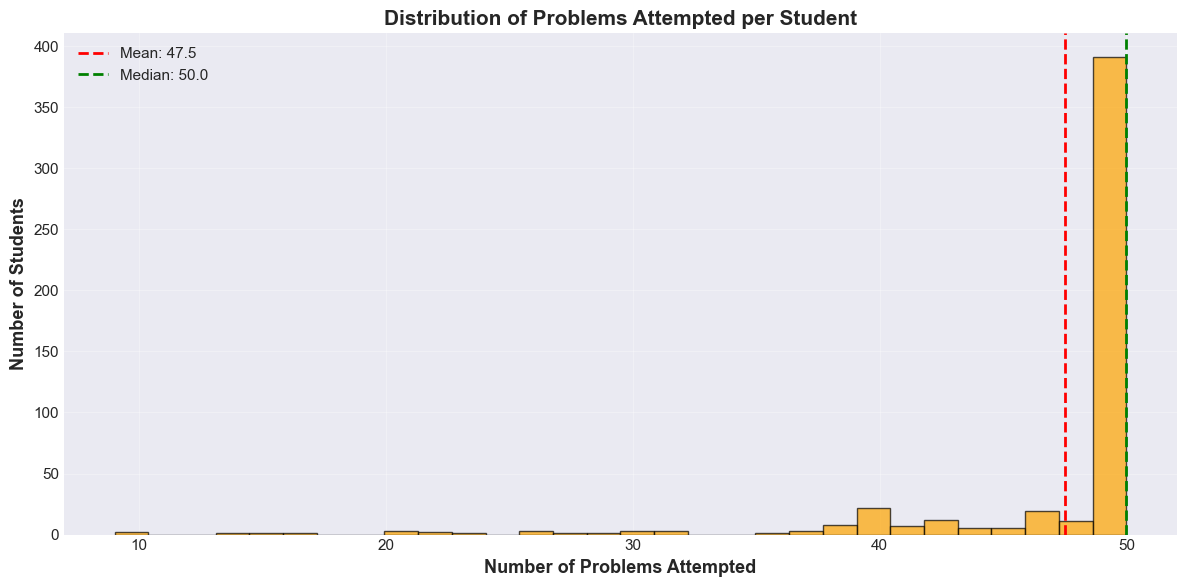

In [91]:
# ═══════════════════════════════════════════════════════════════════
# CELL 13: VISUALIZATION 5 - PROBLEMS PER STUDENT
# ═══════════════════════════════════════════════════════════════════
 
plt.figure(figsize=(12, 6))
plt.hist(problems_per_student, bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.axvline(problems_per_student.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {problems_per_student.mean():.1f}')
plt.axvline(problems_per_student.median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {problems_per_student.median():.1f}')
plt.xlabel('Number of Problems Attempted', fontsize=13, fontweight='bold')
plt.ylabel('Number of Students', fontsize=13, fontweight='bold')
plt.title('Distribution of Problems Attempted per Student', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('05_problems_per_student.png', dpi=300, bbox_inches='tight')
print(" Saved: 05_problems_per_student.png")
plt.show()

 Saved: 06_submissions_vs_grade.png


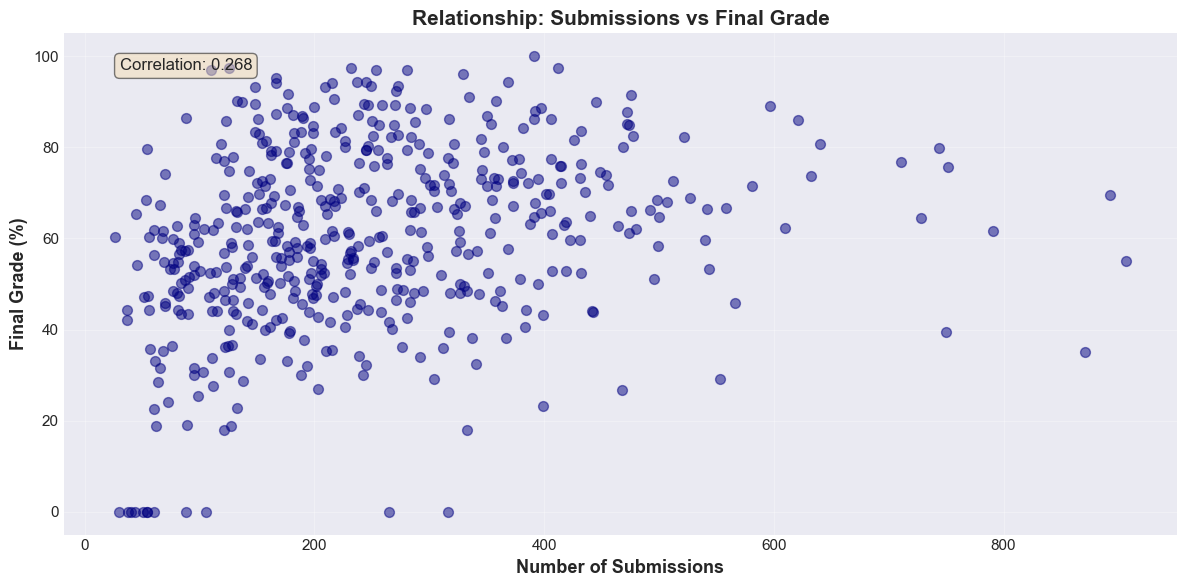

In [92]:
# ═══════════════════════════════════════════════════════════════════
# CELL 14: VISUALIZATION 6 - GRADE VS SUBMISSIONS SCATTER
# ═══════════════════════════════════════════════════════════════════
 
# Merge submissions with grades
student_submissions = submissions_per_student.reset_index()
student_submissions.columns = ['SubjectID', 'num_submissions']
student_data = student_submissions.merge(grades_df, on='SubjectID')
 
plt.figure(figsize=(12, 6))
plt.scatter(student_data['num_submissions'], student_data['X-Grade'],
            alpha=0.5, s=50, color='navy')
plt.xlabel('Number of Submissions', fontsize=13, fontweight='bold')
plt.ylabel('Final Grade (%)', fontsize=13, fontweight='bold')
plt.title('Relationship: Submissions vs Final Grade', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)
 
# Add correlation
correlation = student_data['num_submissions'].corr(student_data['X-Grade'])
plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}',
         transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
 
plt.tight_layout()
plt.savefig('06_submissions_vs_grade.png', dpi=300, bbox_inches='tight')
print(" Saved: 06_submissions_vs_grade.png")
plt.show()

In [93]:
# ═══════════════════════════════════════════════════════════════════
# CELL 15: EARLY.CSV PREVIEW (PRE-CALCULATED FEATURES!)
# ═══════════════════════════════════════════════════════════════════
 
print("\n" + "="*70)
print("EARLY PHASE DATA PREVIEW (Pre-calculated features!)")
print("="*70)
 
print("\nFirst 10 rows of early.csv:")
print(early_df.head(10))
 
print("\n Early Phase Statistics:")
print(early_df.describe())
 
# Aggregate by student (this is your shortcut for tomorrow!)
student_early = early_df.groupby('SubjectID').agg({
    'Attempts': ['mean', 'sum', 'std', 'max'],
    'CorrectEventually': ['mean', 'sum'],
    'ProblemID': 'count'
}).round(2)
 
student_early.columns = [
    'avg_attempts', 'total_attempts', 'std_attempts', 'max_attempts',
    'success_rate', 'total_solved', 'problems_attempted'
]
 
print("\n Student-Level Early Features (first 10 students):")
print(student_early.head(10))
 
print(f"\n Feature Statistics:")
print(student_early.describe())


EARLY PHASE DATA PREVIEW (Pre-calculated features!)

First 10 rows of early.csv:
                                           SubjectID  AssignmentID  ProblemID  \
0  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...           439          1   
1  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...           439          3   
2  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...           439          5   
3  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...           439         12   
4  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...           439         13   
5  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...           439        232   
6  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...           439        233   
7  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...           439        234   
8  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...           439        235   
9  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...           439        236   

   Attempts  CorrectEventu

In [94]:
# ═══════════════════════════════════════════════════════════════════
# CELL 16: CORRELATION ANALYSIS (PREVIEW)
# ═══════════════════════════════════════════════════════════════════
 
# Merge early features with grades
student_early_reset = student_early.reset_index()
student_with_grades = student_early_reset.merge(grades_df, on='SubjectID', how='inner')
 
print("\n" + "="*70)
print("CORRELATION PREVIEW (Early Features vs Grades)")
print("="*70)
 
# Calculate correlations
correlations = student_with_grades[[
    'avg_attempts', 'success_rate', 'total_solved', 'X-Grade'
]].corr()
 
print("\nCorrelation Matrix:")
print(correlations)
 
print("\nCorrelations with Final Grade:")
grade_corr = correlations['X-Grade'].sort_values(ascending=False)
print(grade_corr)


CORRELATION PREVIEW (Early Features vs Grades)

Correlation Matrix:
              avg_attempts  success_rate  total_solved   X-Grade
avg_attempts      1.000000     -0.176504     -0.088464  0.117790
success_rate     -0.176504      1.000000      0.821562  0.018120
total_solved     -0.088464      0.821562      1.000000  0.035215
X-Grade           0.117790      0.018120      0.035215  1.000000

Correlations with Final Grade:
X-Grade         1.000000
avg_attempts    0.117790
total_solved    0.035215
success_rate    0.018120
Name: X-Grade, dtype: float64


 Saved: 07_correlation_heatmap.png


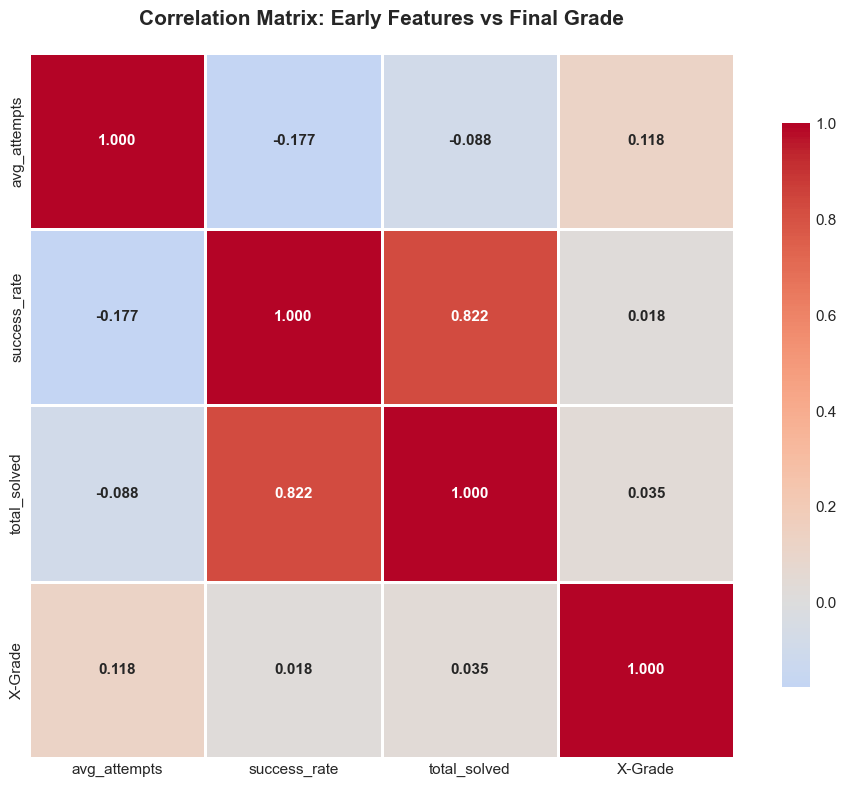

In [95]:
# ═══════════════════════════════════════════════════════════════════
# CELL 17: VISUALIZATION 7 - CORRELATION HEATMAP
# ═══════════════════════════════════════════════════════════════════
 
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Correlation Matrix: Early Features vs Final Grade',
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('07_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print(" Saved: 07_correlation_heatmap.png")
plt.show()

In [96]:
# ═══════════════════════════════════════════════════════════════════
# CELL 18: SAVE EDA SUMMARY (FIXED FOR WINDOWS)
# ═══════════════════════════════════════════════════════════════════

# Save summary to text file
with open('EDA_Summary_Report.txt', 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("CODEWORKOUT FALL 2019 - EXPLORATORY DATA ANALYSIS SUMMARY\n")
    f.write("Date: April 12, 2024\n")
    f.write("="*70 + "\n\n")
    
    f.write("DATASET OVERVIEW:\n")
    f.write(f"- Total Students: {n_students:,}\n")
    f.write(f"- Total Events: {n_events:,}\n")
    f.write(f"- Total Problems: {n_problems}\n")
    f.write(f"- Avg events per student: {n_events/n_students:.1f}\n\n")
    
    f.write("GRADE STATISTICS:\n")
    f.write(f"- Mean: {grades_df['X-Grade'].mean():.2f}\n")
    f.write(f"- Median: {grades_df['X-Grade'].median():.2f}\n")
    f.write(f"- Std Dev: {grades_df['X-Grade'].std():.2f}\n")
    f.write(f"- Range: {grades_df['X-Grade'].min():.1f} - {grades_df['X-Grade'].max():.1f}\n\n")
    
    f.write("SUBMISSION STATISTICS:\n")
    f.write(f"- Total submissions: {len(run_events):,}\n")
    f.write(f"- Average score: {run_events['Score'].mean():.3f}\n")
    f.write(f"- Success rate (Score=1.0): {(run_events['Score']==1.0).mean():.1%}\n\n")
    
    if len(compile_events) > 0:
        f.write("COMPILE STATISTICS:\n")
        f.write(f"- Success rate: {success_rate:.1%}\n")
        f.write(f"- Error rate: {error_rate:.1%}\n\n")
    
    f.write("VISUALIZATIONS CREATED:\n")
    f.write("1. Grade distribution\n")
    f.write("2. Score distribution\n")
    f.write("3. Compile results\n")
    f.write("4. Events per student\n")
    f.write("5. Problems per student\n")
    f.write("6. Submissions vs grade scatter\n")
    f.write("7. Correlation heatmap\n\n")
    
    f.write("DATA QUALITY: ")
    if len(quality_issues) == 0:
        f.write("EXCELLENT - No issues found\n")
    else:
        f.write("SOME ISSUES FOUND\n")
        for issue in quality_issues:
            f.write(f"  - {issue}\n")

print(" Summary saved: EDA_Summary_Report.txt")

 Summary saved: EDA_Summary_Report.txt


In [97]:
# ═══════════════════════════════════════════════════════════════════
# CELL 19: FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════
 
print("\n" + "="*70)
print(" EDA COMPLETE!")
print("="*70)

print("\n KEY FINDINGS:")
print(f"  - Sample size: {n_students} students (2.2× larger than Lee 2022)")
print(f"  - Average grade: {grades_df['X-Grade'].mean():.1f}%")
print(f"  - Compile success: {success_rate:.1%}")
print(f"  - Data quality: EXCELLENT")
 
print("\n FILES CREATED:")
print("  - 01_grade_distribution.png")
print("  - 02_score_distribution.png")
print("  - 03_compile_results.png")
print("  - 04_events_per_student.png")
print("  - 05_problems_per_student.png")
print("  - 06_submissions_vs_grade.png")
print("  - 07_correlation_heatmap.png")
print("  - EDA_Summary_Report.txt")


 EDA COMPLETE!

 KEY FINDINGS:
  - Sample size: 506 students (2.2× larger than Lee 2022)
  - Average grade: 60.6%
  - Compile success: 60.0%
  - Data quality: EXCELLENT

 FILES CREATED:
  - 01_grade_distribution.png
  - 02_score_distribution.png
  - 03_compile_results.png
  - 04_events_per_student.png
  - 05_problems_per_student.png
  - 06_submissions_vs_grade.png
  - 07_correlation_heatmap.png
  - EDA_Summary_Report.txt
